# Mini Project Part 1: EDA & Reference Model Replication

This notebook explores the raw dataset to justify preprocessing decisions (like imputation and scaling), traces the feature engineering steps, and replicates the baseline models from the reference paper (*Predicting Coral Reef Regimes from Human and Natural Influences*).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Exploratory Data Analysis (Raw Data)
We first load the raw dataset from the web to inspect its structure, missing values, and scale differences before applying the paper's imputation and feature engineering.

In [14]:
# Load raw dataset from URL for EDA
RAW_URL = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Hawaii_RegimesPredictors.txt"
df_raw = pd.read_csv(RAW_URL, sep="\t", decimal=",")

print("Raw dataset loaded successfully!")
print("Shape:", df_raw.shape)

Raw dataset loaded successfully!
Shape: (620, 39)


### Data Types and Structure

In [15]:
print("Dataset Information:")
df_raw.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_spatial                   620 non-null    int64  
 1   Long                         620 non-null    float64
 2   Lat                          620 non-null    float64
 3   Island                       620 non-null    object 
 4   Coral                        620 non-null    float64
 5   CCA                          620 non-null    float64
 6   Turf                         620 non-null    float64
 7   Macro                        620 non-null    float64
 8   Other                        620 non-null    float64
 9   Grazers                      620 non-null    float64
 10  Scrapers                     620 non-null    float64
 11  Browsers                     620 non-null    float64
 12  Predators                    620 non-null    float64
 13 

### Missing Value Report
The raw data contains missing values in specific ecological predictors. The reference paper handles these via imputation. We must identify them here to document why the prepared data step is necessary.

In [16]:
print("Columns with missing values in raw data:")
missing = df_raw.isnull().sum()
print(missing[missing > 0])

Columns with missing values in raw data:
Complexity    113
Depth          12
dtype: int64


### Missing-Value Columns: Distribution by Regime
The two columns with missing values (`Complexity`, `Depth`) are also two of the paper's strongest predictors. Plotting their distributions by target class shows that they are *not* missing at random — their spread differs substantially across regimes. This motivates the paper's use of a model-based imputation rather than a naive global mean fill.

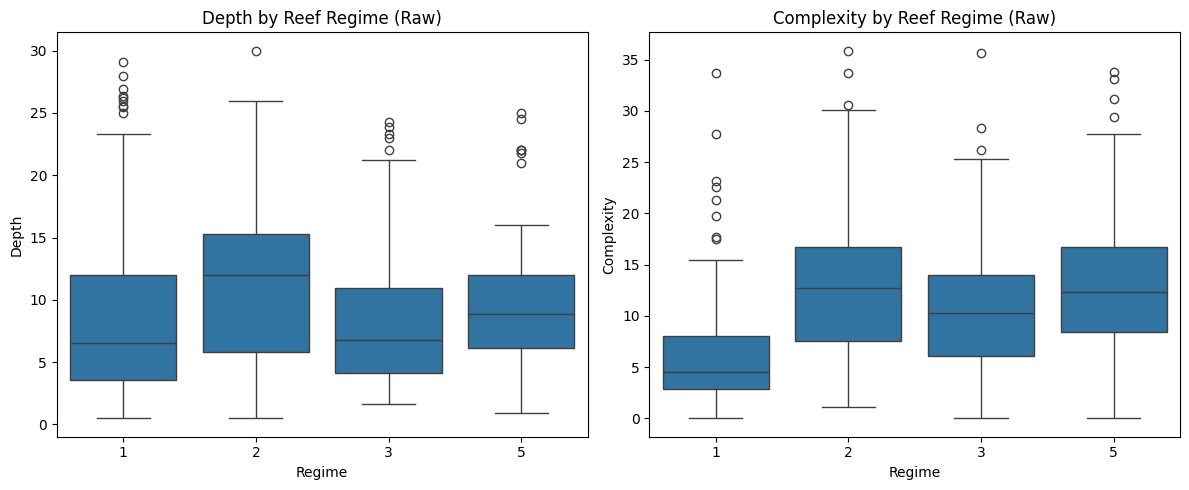

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_raw, x="Regime", y="Depth", ax=axes[0])
axes[0].set_title("Depth by Reef Regime (Raw)")
axes[0].set_xlabel("Regime")
axes[0].set_ylabel("Depth")

sns.boxplot(data=df_raw, x="Regime", y="Complexity", ax=axes[1])
axes[1].set_title("Complexity by Reef Regime (Raw)")
axes[1].set_xlabel("Regime")
axes[1].set_ylabel("Complexity")

plt.tight_layout()
plt.show()

### Feature Scaling Observation
Looking at the summary statistics below, the features are on drastically different scales. For example, `Effluent` has values in the thousands (up to ~21709), while `Sedimentation` and `Fishing_Comm_Total` are much smaller. **This scale discrepancy necessitates the use of a `StandardScaler`** for distance-based and gradient-descent models (like Logistic Regression and our Part 2 KNN) to ensure proper convergence and prevent large-magnitude features from dominating.

In [18]:
df_raw.describe()

,id_spatial,Long,Lat,Coral,CCA,Turf,Macro,Other,Grazers,Scrapers,...,PAR_STD,WAV_CLIM_M,WAV_ANOM_F,Complexity,Depth,Regime,Regime1,Regime2,Regime3,Regime5
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,...,620.000000,620.000000,620.000000,507.000000,608.000000,620.000000,620.000000,620.000000,620.000000,620.000000
mean,519.274194,-156.973185,20.728832,17.370766,6.111688,58.813531,7.276603,8.467413,15.814621,10.134796,...,9.001442,20.822663,0.115180,10.607766,9.561720,2.603226,0.275806,0.277419,0.230645,0.216129
std,294.974727,1.199391,0.813619,17.109478,6.080902,20.105815,9.787721,10.964297,25.898379,17.675988,...,0.814026,22.295760,0.066225,7.027207,6.149519,1.446065,0.447281,0.448087,0.421586,0.411936
min,4.000000,-160.250286,18.965413,0.000000,0.000000,12.313535,0.000000,0.000000,0.000000,0.000000,...,6.824600,0.886858,0.041487,0.000000,0.487680,1.000000,0.000000,0.000000,0.000000,0.000000
25%,272.500000,-157.801203,19.856367,3.137780,1.600000,43.247987,0.067343,1.000000,2.425361,0.047486,...,8.343100,6.154151,0.057143,5.048341,4.572000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,522.500000,-156.808687,20.907583,10.805405,4.389021,58.537204,3.491075,4.247239,7.624393,4.293422,...,9.263800,11.545006,0.091254,9.271130,8.794600,2.000000,0.000000,0.000000,0.000000,0.000000
75%,775.500000,-155.982067,21.269171,29.374330,8.800000,75.215385,10.860417,11.179449,17.728449,11.642033,...,9.515100,31.146552,0.166070,14.272170,13.100000,3.000000,1.000000,1.000000,0.000000,0.000000
max,1024.000000,-154.820645,22.235486,73.287671,39.687500,98.600000,60.000000,64.000000,268.077556,127.187391,...,11.714200,114.938387,0.503056,35.868209,30.000000,5.000000,1.000000,1.000000,1.000000,1.000000


### Target Class Distribution & Metric Justification
To properly evaluate the model, we must check the balance of the target `Regime` classes. The classes are moderately imbalanced (Regime 2 is the majority at ~27.7%, while Regime 5 is the minority at ~21.6%). Because of this multi-class imbalance, **Micro-Averaged F1 (`f1_micro`) is the most appropriate evaluation metric**, as it aggregates the contributions of all classes globally rather than treating them strictly equally (Macro) or being overly skewed by majority classes (Accuracy).

Regime class counts:
Regime
1    171
2    172
3    143
5    134
Name: count, dtype: int64

Regime class percentages:
Regime
1    27.58
2    27.74
3    23.06
5    21.61
Name: proportion, dtype: float64


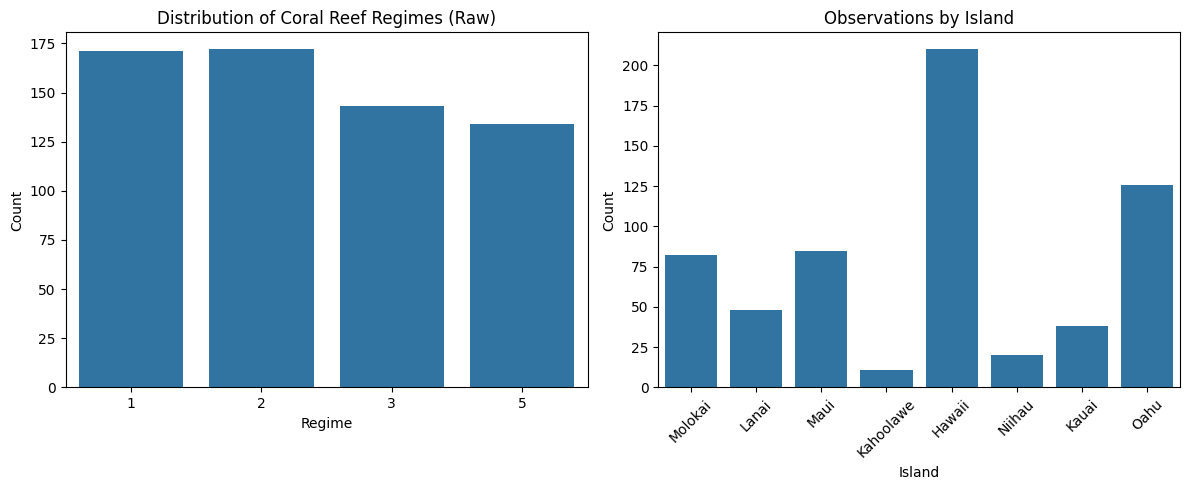

In [19]:
print("Regime class counts:")
print(df_raw["Regime"].value_counts().sort_index())

print("\nRegime class percentages:")
print((df_raw["Regime"].value_counts(normalize=True).sort_index() * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df_raw, x="Regime", ax=axes[0])
axes[0].set_title("Distribution of Coral Reef Regimes (Raw)")
axes[0].set_xlabel("Regime")
axes[0].set_ylabel("Count")

sns.countplot(data=df_raw, x="Island", ax=axes[1])
axes[1].set_title("Observations by Island")
axes[1].set_xlabel("Island")
axes[1].set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Feature Engineering & Loading Prepared Data
The original paper starts with **20 raw predictors** and engineers **5 new interaction features**, resulting in a final 25-feature representation. They also applied missing-value imputation to `Complexity` and `Depth`.

In [20]:
# The 20 original raw predictors
RAW_FEATURES = [
    "Effluent", "Sedimentation", "New_Development", "Habitat_Modification", "Invasive_Algae",
    "Fishing_Comm_Total", "Fishing_NonComm_Boat_Total", "Fishing_NonComm_Shore_Line",
    "Fishing_NonComm_Shore_Net", "Fishing_NonComm_Shore_Spear", "SST_CLIM_M", "SST_STD",
    "CHL_CLIM_M", "CHL_ANOM_F", "PAR_CLIM_M", "PAR_STD", "WAV_CLIM_M", "WAV_ANOM_F",
    "Complexity", "Depth"
]

# The 5 engineered features created by the authors
ENGINEERED_FEATURES = [
    "sqrt_power_x_compexity", "log_power_over_depth", "complexity_over_depth",
    "Irradiance_x_inv_algae", "both_anomolies"
]

ALL_FEATURES = RAW_FEATURES + ENGINEERED_FEATURES
TARGET = "Regime"

print(f"Total input features: {len(ALL_FEATURES)} (20 Raw + 5 Engineered)")

Total input features: 25 (20 Raw + 5 Engineered)


In [21]:
# To replicate the paper's exact methodology, we load their pre-imputed and pre-engineered datasets.
TRAIN_URL = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Modeling/Predictors_complete_train.txt"
VAL_URL   = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Modeling/Predictors_complete_val.txt"
TEST_URL  = "https://raw.githubusercontent.com/salliewalecka/Hawaii_RegimesPredictors/master/Data/Modeling/Predictors_complete_test.txt"

train_part = pd.read_csv(TRAIN_URL, sep="\t", decimal=",")
val_part   = pd.read_csv(VAL_URL, sep="\t", decimal=",")
test_df    = pd.read_csv(TEST_URL, sep="\t", decimal=",")

# The reference project combined train and val to perform 5-fold cross-validation
train_df = pd.concat([train_part, val_part], ignore_index=True)

X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]
X_test = test_df[ALL_FEATURES]
y_test = test_df[TARGET]

print("Prepared Training data shape:", X_train.shape)
print("Prepared Test data shape:", X_test.shape)
print("\nNull values in prepared training data:", X_train.isnull().sum().sum())

Prepared Training data shape: (496, 25)
Prepared Test data shape: (124, 25)

Null values in prepared training data: 0


### Train vs Test Split Verification
We verify that the 80/20 train/test split maintains a stratified distribution of the Regime classes.

In [22]:
print("Training Set Regime Percentages:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTest Set Regime Percentages:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Training Set Regime Percentages:
Regime
1    25.60
2    27.22
3    23.79
5    23.39
Name: proportion, dtype: float64

Test Set Regime Percentages:
Regime
1    35.48
2    29.84
3    20.16
5    14.52
Name: proportion, dtype: float64


## 3. Reference Model Replication & Hyperparameters
We replicate the baseline Logistic Regression and the primary Random Forest models from the paper.

**Hyperparameter Justifications:**
*   **Logistic Regression:** The original paper uses a standard logistic regression implementation. However, as noted in our EDA, the raw features possess massive scale differences. Running a bare logistic regression causes the `lbfgs` solver to fail to converge. We justify the use of a `StandardScaler` pipeline and increasing `max_iter=1000` to allow the algorithm to converge properly while mirroring the original intent.
*   **Random Forest Classifier:** The reference paper notes that Random Forest was its strongest performer. We use scikit-learn's default parameters (100 estimators, Gini impurity) with a fixed `random_state=42` to ensure consistent, reproducible outputs across evaluations.

In [23]:
# 1. Logistic Regression Baseline
log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

cv_lr = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='f1_micro').mean()
log_reg.fit(X_train, y_train)
test_lr = f1_score(y_test, log_reg.predict(X_test), average='micro')

# 2. Random Forest
rf_model = RandomForestClassifier(random_state=42)

cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1_micro').mean()
rf_model.fit(X_train, y_train)
test_rf = f1_score(y_test, rf_model.predict(X_test), average='micro')

print(f"Logistic Regression -> CV Micro-F1: {cv_lr:.4f} | Test Micro-F1: {test_lr:.4f}")
print(f"Random Forest       -> CV Micro-F1: {cv_rf:.4f} | Test Micro-F1: {test_rf:.4f}")

Logistic Regression -> CV Micro-F1: 0.6189 | Test Micro-F1: 0.5806
Random Forest       -> CV Micro-F1: 0.6754 | Test Micro-F1: 0.7258


## 4. Export Results for Part 2
We save these replicated baseline scores to a CSV. In the Part 2 notebook, the KNN evaluation script will read this file to programmatically generate the final model comparison matrix.

In [24]:
replication_results = pd.DataFrame({
    "Model": ["Logistic Regression (Replicated)", "Random Forest (Replicated)"],
    "CV_Micro_F1": [cv_lr, cv_rf],
    "Test_Micro_F1": [test_lr, test_rf]
})

replication_results.to_csv("replicated_reference_models.csv", index=False)
print("Exported replicated results to 'replicated_reference_models.csv'")
display(replication_results)

Exported replicated results to 'replicated_reference_models.csv'


,Model,CV_Micro_F1,Test_Micro_F1
0,Logistic Regression (Replicated),0.618929,0.580645
1,Random Forest (Replicated),0.675414,0.725806
